# 04 — Refining the headline figure
### *Rhodopseudomonas palustris* CGA009 (iAN1128) · PHB on p-coumarate

Notebook `03` builds the target list and renders the headline heatmap
(*Round-0 CRISPRi targets — after downselection*) through the locked renderer in `lib/nb71_lib.py`.
**This notebook refines that figure without touching `nb71_lib`.** It imports only the *data*
(`nb71_lib.get_data()` — which just reads the NB60–64 result CSVs + the curated AI table) and
re-implements the renderer inline as `heatmap_v2()`, so the figure can be iterated freely.

**v1 changes (this pass):**

| # | Request | How |
|---|---|---|
| 1 | **Remove the title** | `heatmap_v2` never calls `set_title` |
| 2 | **y-labels = shorthand gene name only** (e.g. `phaR`) | new `short` column: curated symbol where one exists, else a conventional enzyme symbol (`EXTRA_SYMBOLS`), else the RPA locus |
| 3 | **all y-labels solid black** | tick labels forced to `black`, normal weight (the old per-source colour/bold encoding is dropped) |

**Every gene name is cross-validated against the CGA009 RefSeq annotation** (assembly `GCF_000195775.1`)
and UniProt (Part 1). That check turned up real errors in the upstream AI-prediction table — two mislabelled
symbols (`accA`→`accD`, `sdhA`→`sdhB`) and **seven regulator rows whose RPA locus points at an unrelated
gene** (`phaZ`, `phaR`, `glnB`, `glnK`, `ntrB`, `nifA`, `regB`); those corrections are in **Part 1b**.

Outputs are written with a **new `nb04_` prefix** so the NB03 figure (`nb71_downselected.*`) is never
overwritten. **Part 3** adds a second view — an area-proportional 4-set Euler diagram of how the four
methods' hits on the 41 targets overlap.

## Part 0 · Load the data and apply the downselection

`nb71_lib.get_data()` rebuilds the combined **51-target** FBA+AI table (identical to NB03 Part 5) and, as a
side effect, populates `nb71_lib._STATE` with the per-method cell-intensity maps (`gmraw`, `gmmag`) the
renderer needs. We then apply the same 10-gene literature cut list NB03 uses to reach the **41 kept**
targets. (The cut set is reproduced here as a literal so this notebook is self-contained; it matches
`GROUPS_TO_APPLY` in NB03.)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "lib")); sys.path.insert(0, str(Path.cwd().parent / "lib" / "FluxRETAP"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nb60_lib as L, nb71_lib as NB
pd.set_option("display.width", 260); pd.set_option("display.max_colwidth", 60)

rows, ai = NB.get_data()                 # 51-target combined table; also populates NB._STATE (gmraw/gmmag)

# the 10 loci NB03 cuts (regulators are deliberately KEPT) -> 41 remain. See NB03 Part 5 CUT_LIBRARY.
CUTS = {"RPA4566",  # ackA   (redundant duplicate)
        "RPA0426",  # fabH   (redundant duplicate)
        "RPA2019",  # fabF   (redundant duplicate)
        "RPA4394",  # isocitrate lyase (counter-evidence)
        "RPA0670",  # hbaA   (counter-evidence)
        "RPA2967",  # glnA   (single-guide-infeasible, isozyme redundancy)
        "RPA0891",  # gltB   (N-sensor, metabolic)
        "RPA4180",  # pntA   (high-risk metabolic)
        "RPA2937",  # nuoF   (high-risk metabolic)
        "RPA0175"}  # atpA   (high-risk metabolic)
df = rows[~rows.gene.isin(CUTS)].reset_index(drop=True)
print(f"combined {len(rows)} -> downselected {len(df)} kept  |  sources: {df.source.value_counts().to_dict()}")

combined 51 -> downselected 41 kept  |  sources: {'FBA': 23, 'AI': 9, 'FBA+AI': 6, 'AI+FBA': 3}


## Part 1 · Shorthand gene names for the y-axis (cross-validated against NCBI RefSeq)

Every symbol below was **cross-validated against the CGA009 RefSeq annotation** (assembly
`GCF_000195775.1`, chromosome `NC_005296.1`) and UniProt (taxid 258594). Two maps:

- **`EXTRA_SYMBOLS`** — the FBA-only loci, which the iAN1128 model stores as bare `RPA####` tags. Symbols
  that RefSeq/UniProt assign by name are marked `NCBI`/`UniProt`; the rest are the **conventional symbol for
  the annotated enzyme** and marked `conv` (function-confirmed by the RefSeq product, but RefSeq assigns no
  symbol). `RPA0818` → **`fadB`**: RefSeq calls it a 3-hydroxyacyl-CoA dehydrogenase, but in the model it
  carries the hydratase + dehydrogenase + (S)-3-hydroxybutanoyl-CoA epimerase (R03276) activities of a
  multifunctional β-oxidation enzyme — a FadB (it is FluxRETAP's #1 hit, via that epimerase reaction).
- **`SYMBOL_FIX`** — two AI-table symbols that were **wrong for their locus** and are corrected here:
  `RPA0071` is **accD** (carboxyl-transferase β), not accA; `RPA0216` is **sdhB** (the Fe-S subunit) — the
  true `sdhA` flavoprotein is `RPA0217`.

**The y-axis now shows the locus after each gene name** (in muted grey). For the seven AI rows whose original
`nb71_lib` locus points at an unrelated gene, the figure shows the **corrected, RefSeq-verified** locus
(`DISPLAY_LOCUS`) — never the wrong tag. Full provenance for those corrections is in **Part 1b**.

`short_name()` order: **`SYMBOL_FIX` → curated `ai_symbol` → `EXTRA_SYMBOLS` → RPA locus.**

In [2]:
# FBA-only loci -> gene symbol. src tag: NCBI = RefSeq gene= symbol; UniProt = UniProt primary; conv =
# conventional symbol for the RefSeq-annotated enzyme (RefSeq assigns no symbol, but the product confirms it).
EXTRA_SYMBOLS = {
    "RPA0411": "ppa",    # NCBI  inorganic diphosphatase
    "RPA3056": "ndk",    # NCBI  nucleoside-diphosphate kinase
    "RPA1051": "ppdK",   # NCBI  pyruvate, phosphate dikinase
    "RPA1331": "mqo",    # NCBI  malate:quinone oxidoreductase
    "RPA1580": "putA",   # NCBI  proline dehydrogenase/P5C dehydrogenase (bifunctional)
    "RPA3815": "rpe",    # NCBI  ribulose-phosphate 3-epimerase
    "RPA3636": "zwf",    # NCBI  glucose-6-phosphate dehydrogenase
    "RPA4410": "glpD",   # NCBI  glycerol-3-phosphate dehydrogenase
    "RPA0163": "proB",   # NCBI  glutamate 5-kinase
    "RPA4211": "glsA",   # UniProt glutaminase
    "RPA0360": "pckA",   # UniProt PEP carboxykinase (ATP)
    "RPA4721": "por",    # conv  2-oxoacid:acceptor oxidoreductase (pyruvate:ferredoxin oxidoreductase)
    "RPA3229": "adk",    # conv  adenylate kinase
    "RPA1578": "fpr",    # conv  ferredoxin--NADP reductase
    "RPA3042": "maeB",   # conv  NADP-dependent malic enzyme
    "RPA0822": "gshA",   # conv  glutamate--cysteine ligase
    "RPA3634": "pgi",    # conv  bifunctional transaldolase/phosphoglucose isomerase (pgi activity)
    # --- newly identified from the RefSeq product (were shown as loci in v1) ---
    "RPA3173": "acyP",   # UniProt acylphosphatase (hydrolyses 1,3-BPG -> matches model rxn R01515)
    "RPA4727": "glgP",   # conv  glycogen/starch/alpha-glucan phosphorylase
    "RPA3450": "mmsA",   # conv  CoA-acylating methylmalonate-semialdehyde dehydrogenase
    "RPA0560": "mcd",    # UniProt MLYCD; malonyl-CoA decarboxylase
    "RPA0962": "hupS",   # conv  uptake hydrogenase small subunit (provisional; hup vs hox)
    "RPA0818": "fadB",   # conv  multifunctional beta-oxidation enzyme (dehydratase/dehydrogenase/epimerase); FluxRETAP #1 via its epimerase rxn R03276
}
# AI-table symbols that were WRONG for their locus (verified vs RefSeq) -> corrected display label:
SYMBOL_FIX = {
    "RPA0071": "accD",   # was 'accA'; RPA0071 = acetyl-CoA carboxylase carboxyltransferase beta (accD)
    "RPA0216": "sdhB",   # was 'sdhA'; RPA0216 = succinate dehydrogenase Fe-S subunit (sdhB). sdhA = RPA0217
}
# Corrected RefSeq-verified loci for the 7 AI rows whose nb71 locus points at an unrelated gene (full
# provenance in Part 1b). Used ONLY for the displayed locus column, so the figure never shows a wrong tag.
DISPLAY_LOCUS = {"RPA1786": "RPA0575", "RPA1795": "RPA0530", "RPA0454": "RPA2966", "RPA0584": "RPA0272/74",
                 "RPA1711": "RPA2592", "RPA4630": "RPA4632", "RPA3332": "RPA0572"}
def short_name(r):
    """Resolve a y-axis gene label: SYMBOL_FIX -> curated ai_symbol -> EXTRA_SYMBOLS -> RPA locus."""
    if r.gene in SYMBOL_FIX:
        return SYMBOL_FIX[r.gene]
    if r.ai_symbol:
        return r.ai_symbol
    return EXTRA_SYMBOLS.get(r.gene, r.gene)

df["short"] = df.apply(short_name, axis=1)
df["dloc"]  = df.gene.map(lambda g: DISPLAY_LOCUS.get(g, g))   # locus shown (grey) after the gene name
_locus = df[df.short == df.gene]
print(f"labelled with a gene symbol: {len(df) - len(_locus)}/{len(df)}  |  still shown as RPA locus: {len(_locus)}")
print("  locus-only rows:", ", ".join(_locus.gene) or "(none)")
df[["gene", "short", "dloc", "ai_symbol", "source", "module", "name"]]

labelled with a gene symbol: 41/41  |  still shown as RPA locus: 0
  locus-only rows: (none)


,gene,short,dloc,ai_symbol,source,module,name
0,RPA4721,por,RPA4721,,FBA,redox,pyruvate:ferredoxin 2-oxidoreductase (CoA-acetylating)
1,RPA3229,adk,RPA3229,,FBA,nuc,ATPAMP phosphotransferase
2,RPA2907,gltA,RPA2907,gltA,FBA+AI,accoa,Citrate oxaloacetate-lyase ((pro-3S)-CH2COO- - acetyl-CoA)
3,RPA4567,pta,RPA4567,pta,FBA+AI,accoa,acetyl-CoAphosphate acetyltransferase
4,RPA0818,fadB,RPA0818,,FBA,accoa,(S)-3-Hydroxybutanoyl-CoA 3-epimerase
5,RPA0411,ppa,RPA0411,,FBA,nuc,Pyrophosphate phosphohydrolase (soluble)
6,RPA1578,fpr,RPA1578,,FBA,redox,FerredoxinNADP+ oxidoreductase
7,RPA3056,ndk,RPA3056,,FBA,nuc,ATPnucleoside-diphosphate phosphatransferase
8,RPA1051,ppdK,RPA1051,,FBA,backbone,"ATPpyruvate,orthophosphate phosphotransferase"
9,RPA0071,accD,RPA0071,accA,FBA+AI,accoa,Acetyl-CoAcarbon-dioxide ligase (ADP-forming)


## Part 1b · Locus cross-validation — AI-table loci that point at the wrong gene

The AI-prediction rows in `nb71_lib` carry hand-curated `RPA####` loci for genes **not in the model**
(regulators, `phaZ`). Cross-checking each against RefSeq `GCF_000195775.1` shows **seven of them point at an
unrelated gene** — the gene *symbol* is right, but the *locus* is wrong. This matters for the wet lab: a
CRISPRi guide designed against the listed locus would repress the wrong gene. The heatmap in Part 2 shows
symbols only (so those labels are still correct), but the **corrected loci below are what to clone against**.
`LOCUS_FIX[nb71_locus] = (symbol, correct_locus, what_the_old_locus_actually_is, note)`.

In [3]:
# Verified against RefSeq GCF_000195775.1 (NC_005296.1) gene features + products, and UniProt taxid 258594.
LOCUS_FIX = {
  "RPA1786": ("phaZ", "RPA0575", "3-hydroxybutyryl-CoA dehydratase (crotonase)", "RefSeq gene=phaZ, PHA depolymerase"),
  "RPA1795": ("phaR", "RPA0530", "cation:proton antiporter",                     "RefSeq gene=phaR, PHA synthesis repressor"),
  "RPA0454": ("glnB", "RPA2966", "universal stress protein",                     "P-II regulator immediately upstream of glnA1 (RPA2967)"),
  "RPA0584": ("glnK", "RPA0272/RPA0274", "RNA-binding accessory protein",        "two P-II paralogs, each in a glnK-amtB operon (RPA0273/RPA0275 = amtB)"),
  "RPA1711": ("ntrB", "RPA2592", "nitroreductase",                               "nitrogen-regulation NR(II) sensor kinase, adjacent to ntrC (RPA2593)"),
  "RPA4630": ("nifA", "RPA4632", "NifB (nitrogenase cofactor biosynthesis)",     "RefSeq gene=nifA; RPA4630 is the neighbouring nifB"),
  "RPA3332": ("regB", "RPA0572", "curli assembly protein CsgF",                  "PrrB/RegB redox sensor kinase; RegA/PrrA = RPA0571"),
}
val = pd.DataFrame([{"symbol": s, "nb71_locus": old, "correct_locus": new,
                     "old_locus_actually_is": act, "basis": note}
                    for old, (s, new, act, note) in LOCUS_FIX.items()])
# also flag prpC: symbol correct but the locus is a pseudogene in CGA009
PSEUDO = {"RPA2394": ("prpC", "2-methylcitrate synthase — RefSeq PSEUDOGENE (partial/non-functional in CGA009)")}
val.to_csv(L.OUT / "nb04_locus_validation.csv", index=False)
print(f"AI-table loci that point at the WRONG gene: {len(val)}  (saved nb04_locus_validation.csv)")
print(f"pseudogene flag: RPA2394 = prpC is a RefSeq pseudogene -> not a viable CRISPRi target\n")
val

AI-table loci that point at the WRONG gene: 7  (saved nb04_locus_validation.csv)
pseudogene flag: RPA2394 = prpC is a RefSeq pseudogene -> not a viable CRISPRi target



,symbol,nb71_locus,correct_locus,old_locus_actually_is,basis
0,phaZ,RPA1786,RPA0575,3-hydroxybutyryl-CoA dehydratase (crotonase),"RefSeq gene=phaZ, PHA depolymerase"
1,phaR,RPA1795,RPA0530,cation:proton antiporter,"RefSeq gene=phaR, PHA synthesis repressor"
2,glnB,RPA0454,RPA2966,universal stress protein,P-II regulator immediately upstream of glnA1 (RPA2967)
3,glnK,RPA0584,RPA0272/RPA0274,RNA-binding accessory protein,"two P-II paralogs, each in a glnK-amtB operon (RPA0273/R..."
4,ntrB,RPA1711,RPA2592,nitroreductase,"nitrogen-regulation NR(II) sensor kinase, adjacent to nt..."
5,nifA,RPA4630,RPA4632,NifB (nitrogenase cofactor biosynthesis),RefSeq gene=nifA; RPA4630 is the neighbouring nifB
6,regB,RPA3332,RPA0572,curli assembly protein CsgF,PrrB/RegB redox sensor kinase; RegA/PrrA = RPA0571


## Part 2 · The refined renderer `heatmap_v2`

Same intensity maps and module ordering as `nb71_lib.heatmap`, with the refinements applied (see the inline
`# CHANGE` markers). **Colour scheme:** the three FBA method columns use a **crimson** ramp (`FBA_CMAP`);
the AI-prediction column uses a **blackberry** ramp (`AI_CMAP`); the module side-bars (and their section
labels) use a muted jewel-tone set (`MOD_COLORS`). All three are defined at the top of the cell — edit
those hex stops to re-theme the figure.

In [4]:
from matplotlib.colors import LinearSegmentedColormap as _LSC
COLS = NB.COLS              # ["FVSEOF", "FluxRETAP", "CASOP"]
MODULES = NB.MODULES        # ordered (module_key, (line1, line2)) side-bar labels

# --- "emo" palette: FBA method columns = crimson ramp, AI column = blackberry ramp (both pale -> deep) ---
FBA_CMAP = _LSC.from_list("crimson",    ["#f2e6e7", "#d9a6ab", "#bc6d76", "#8e3743", "#4f1620"])
AI_CMAP  = _LSC.from_list("blackberry", ["#efe7ee", "#cdadc7", "#a274a0", "#6e4368", "#3b1e39"])
# warm jewel-tone module side-bars (also colour the section labels) — kept in the crimson/blackberry family
# (aubergine / clay / plum / gold / terracotta / berry / wine / ochre / mauve / taupe) so the right edge matches
MOD_COLORS = dict(redox="#6b5a72", backbone="#93685f", accoa="#7a5570", ppp="#a5823f", tca="#a4564a",
                  nreg="#8f5060", phb="#7c3547", aa="#8b7c47", nuc="#956d84", other="#8c827b")
import matplotlib.colors as _mcolors
def _darken(c, f=0.62):   # darker shade of a module colour for the (bolder) section-label text
    r, g, b = _mcolors.to_rgb(c); return (r * f, g * f, b * f)

def heatmap_v2(df, fname=None, caption=True, ax=None, save=True):
    """Refined FBA+AI heatmap. Changes vs nb71_lib.heatmap:
       (1) no title; (2) y-labels = df['short'] gene names (solid black) with df['dloc'] locus in grey
       to the right; (3) no per-source colour/bold on the labels;
       (4) crimson FBA columns + blackberry AI column (see FBA_CMAP / AI_CMAP)."""
    MODc = MOD_COLORS
    gmraw, gmmag = NB._STATE["gmraw"], NB._STATE["gmmag"]
    d = df.copy()
    d["_bri"] = [max([gmmag[m].get(r.blue_gene, 0.0) for m in COLS]
                     + [r.ai_pred if r.ai_pred == r.ai_pred else 0.0]) for _, r in d.iterrows()]
    blocks = [(k, lab, d[d.module == k].sort_values("_bri", ascending=False))
              for k, lab in MODULES if (d.module == k).any()]
    R = pd.concat([s for _, _, s in blocks]).reset_index(drop=True)
    n = len(R); ncol = len(COLS) + 1
    V = np.full((n, ncol), np.nan); Cc = np.full((n, ncol), np.nan)
    for i, r in R.iterrows():
        bg = r["blue_gene"]
        for j, mth in enumerate(COLS):
            if bg in gmraw[mth]: V[i, j] = gmraw[mth][bg]; Cc[i, j] = gmmag[mth][bg]
        if r["ai_pred"] == r["ai_pred"]: V[i, len(COLS)] = r["ai_pred"]; Cc[i, len(COLS)] = r["ai_pred"]
        elif r["ai_flag"]: Cc[i, len(COLS)] = 0.10

    own = ax is None
    if own: fig, ax = plt.subplots(figsize=(11.6, max(6.0, 0.55 * n + 1.9)))
    else: fig = ax.figure

    coolcm = FBA_CMAP.copy(); coolcm.set_bad((0, 0, 0, 0))       # crimson FBA columns
    ax.imshow(np.ma.masked_invalid(np.where(np.arange(ncol) < len(COLS), Cc, np.nan)),
              cmap=coolcm, vmin=0, vmax=1, aspect="auto")
    warmcm = AI_CMAP.copy(); warmcm.set_bad((0, 0, 0, 0))         # blackberry AI column
    so = np.full((n, ncol), np.nan); so[:, len(COLS)] = Cc[:, len(COLS)]
    ax.imshow(np.ma.masked_invalid(so), cmap=warmcm, vmin=0, vmax=1, aspect="auto")
    for i in range(n):
        for j in range(ncol):
            if not np.isnan(V[i, j]):
                ax.text(j, i, f"{V[i, j]:.2f}", ha="center", va="center", fontsize=13,
                        color="white" if Cc[i, j] > 0.5 else "#111")
    _xlab = ["CFSA" if c == "CASOP" else c for c in COLS]   # display: the CASOP column is a CFSA-style sampling method
    ax.set_xticks(range(ncol)); ax.set_xticklabels(_xlab + ["LLM"], fontsize=17.5, color="#111")

    # --- CHANGE 2+3: two-column y-labels -> gene symbol (near-black) + locus (muted grey) to its right.
    # Both columns are right-aligned at fixed x (axes-fraction), so loci form a tidy column against the axis.
    ax.set_yticks(range(n)); ax.set_yticklabels([])
    tr = ax.get_yaxis_transform()          # x in axes-fraction, y in data coordinates
    for i, r in R.iterrows():
        ax.text(-0.008, i, r["dloc"],  transform=tr, ha="right", va="center", fontsize=11.5, color="#555555")
        ax.text(-0.150, i, r["short"], transform=tr, ha="right", va="center", fontsize=14, color="#000000")

    # tiled grid: thin white separators between every row and column
    for i in range(1, n): ax.hlines(i - 0.5, -0.5, ncol - 0.5, color="white", lw=1.6)
    for x in range(1, ncol): ax.axvline(x - 0.5, color="white", lw=3.2)
    ax.axvline(len(COLS) - 0.5, color="#c9c9c9", lw=3.2); ax.tick_params(length=0)
    for s in ax.spines.values(): s.set_visible(False)

    xbar = ncol - 0.5 + 0.16; xtxt = ncol - 0.5 + 0.44; y0 = 0
    for key, (t1, t2), sub in blocks:
        y1 = y0 + len(sub) - 1
        ax.plot([xbar, xbar], [y0 - 0.30, y1 + 0.30], color=MODc[key], lw=8.5,
                solid_capstyle="round", clip_on=False)
        ym = (y0 + y1) / 2.0
        ax.text(xtxt, ym - (0.20 if t2 else 0), t1, color=_darken(MODc[key]), fontsize=15.5,
                fontweight="bold", va="center", ha="left", clip_on=False)
        if t2: ax.text(xtxt, ym + 0.50, t2.replace("AI:", "LLM:"), color="#3f3f3f", fontsize=12.5, va="center", ha="left", clip_on=False)
        if y1 + 0.5 < n - 0.01: ax.axhline(y1 + 0.5, color="#d8d8d8", lw=1.6)   # module boundary (over row lines)
        y0 = y1 + 1

    # --- CHANGE 1: no title, and no top caption (both deliberately omitted) ---
    if caption:
        ax.text(0.0, 1.0 + 0.6 / max(n, 8),
                "Cell shade ∝ signal strength   ·   crimson = FBA method (per-column)   ·   "
                "blackberry = AI literature prior (0–1)",
                transform=ax.transAxes, ha="left", va="bottom", fontsize=9, style="italic", color="#555555")
    ax.set_ylim(n - 0.5, -0.5)
    if own and save and fname:
        for ext in ("png", "svg"):
            fig.savefig(L.FIG / f"{fname}.{ext}", bbox_inches="tight", dpi=170,
                        transparent=False, facecolor="white")
        print(f"saved {L.FIG / (fname + '.png')}  (+ .svg)")
    print(f"rendered {fname or '<inline>'} ({n} genes)")
    return fig

## Part 2b · Render the refined figure (41 kept)

Written to `Results/nb60_targets/figures/nb04_downselected_refined.{png,svg}` — a **new** file; the NB03
headline (`nb71_downselected.*`) is left untouched.

saved C:\Users\jscom\OneDrive\Documents\CGA009_GSM\Release_github\Results\nb60_targets\figures\nb04_downselected_refined.png  (+ .svg)
rendered nb04_downselected_refined (41 genes)


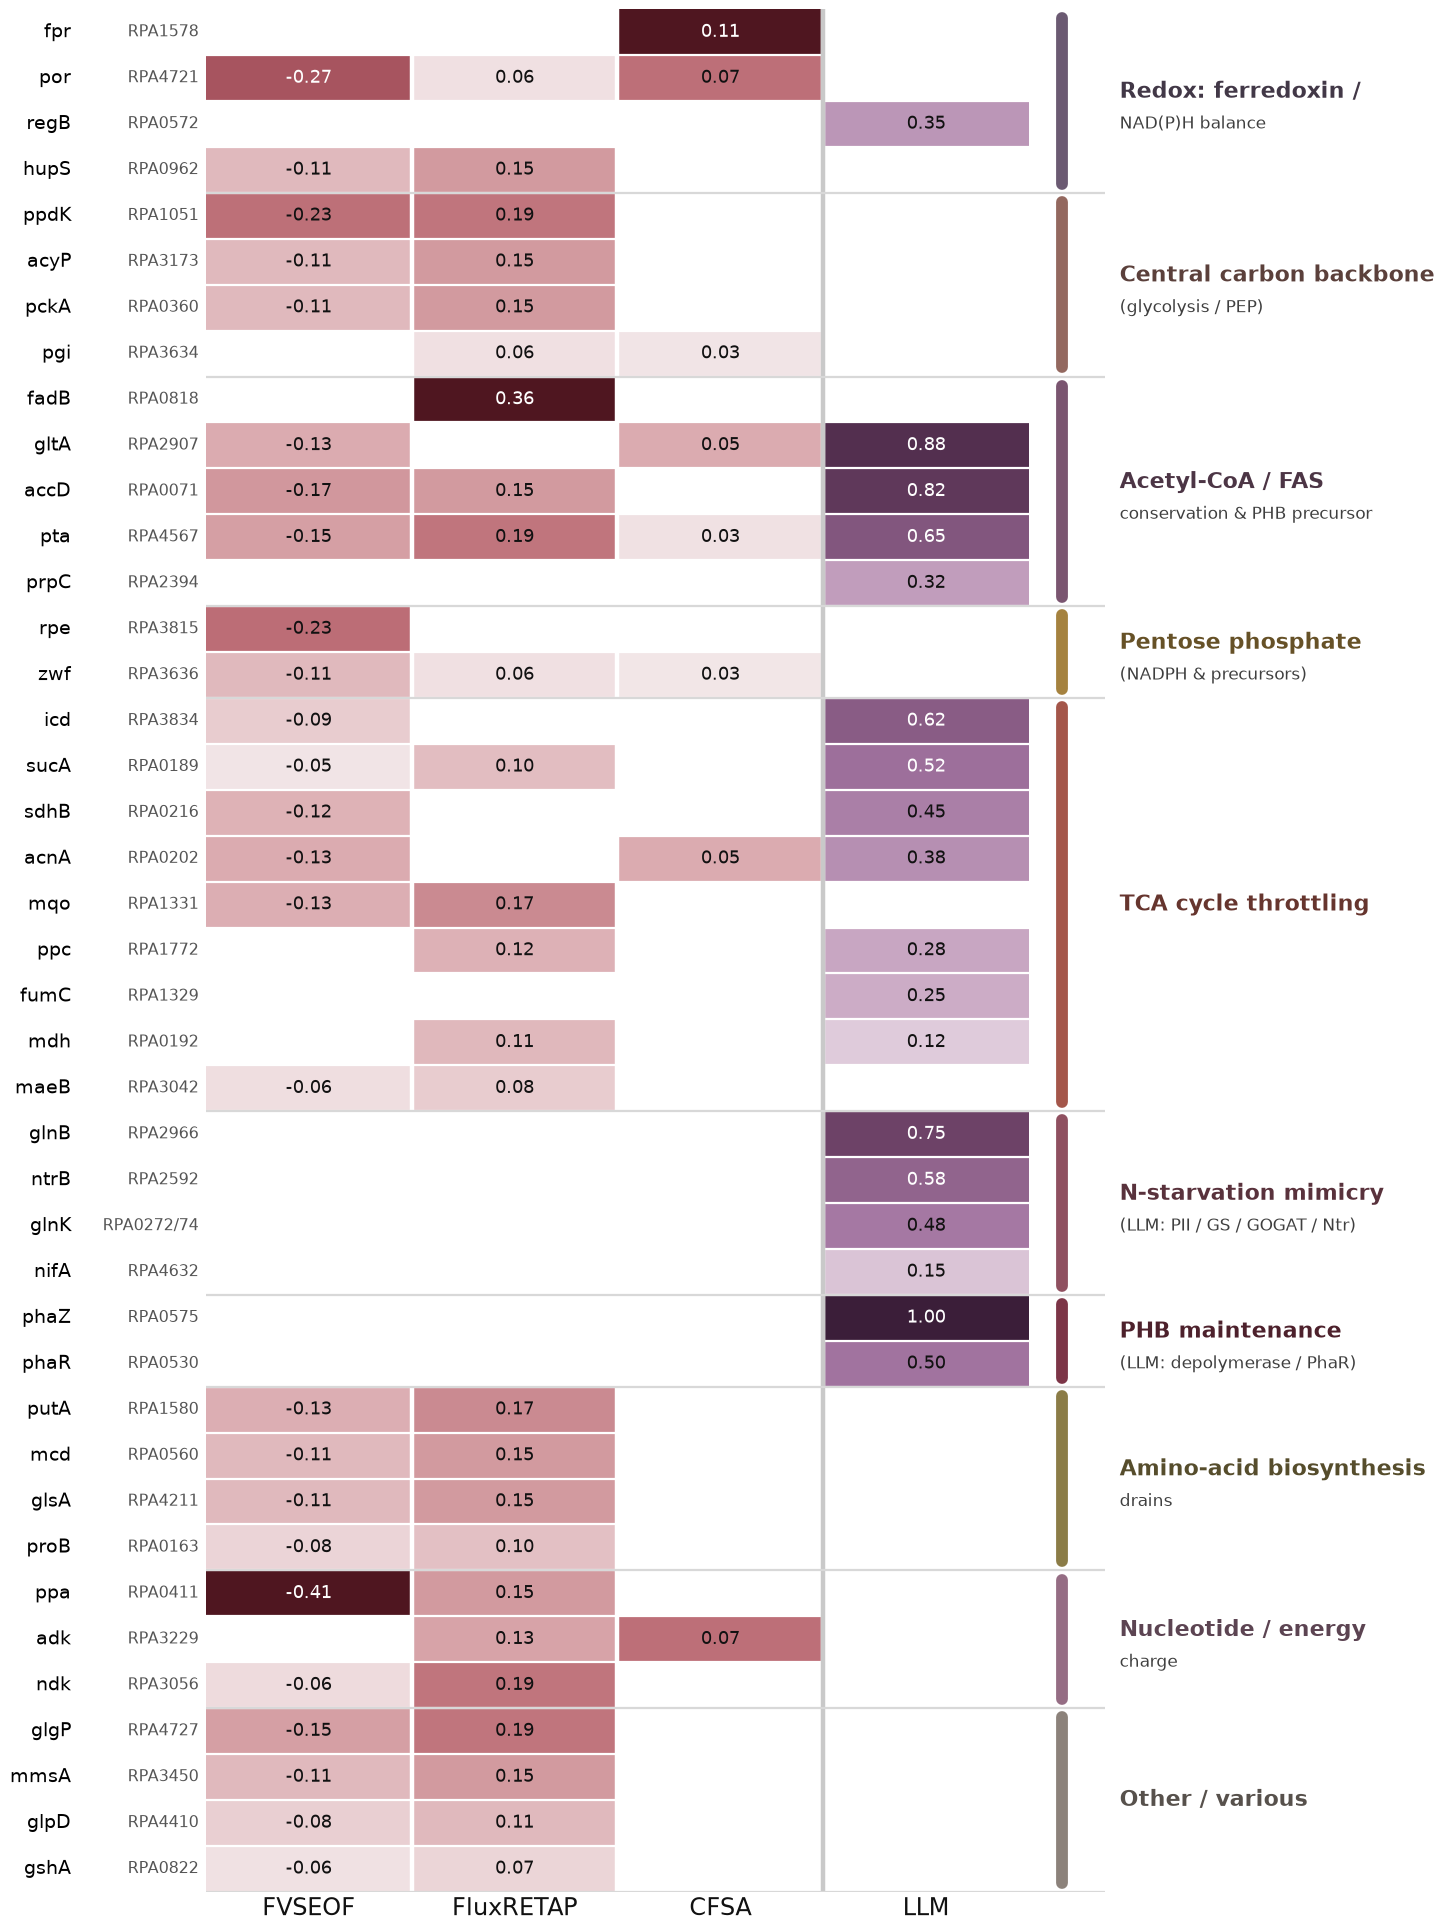

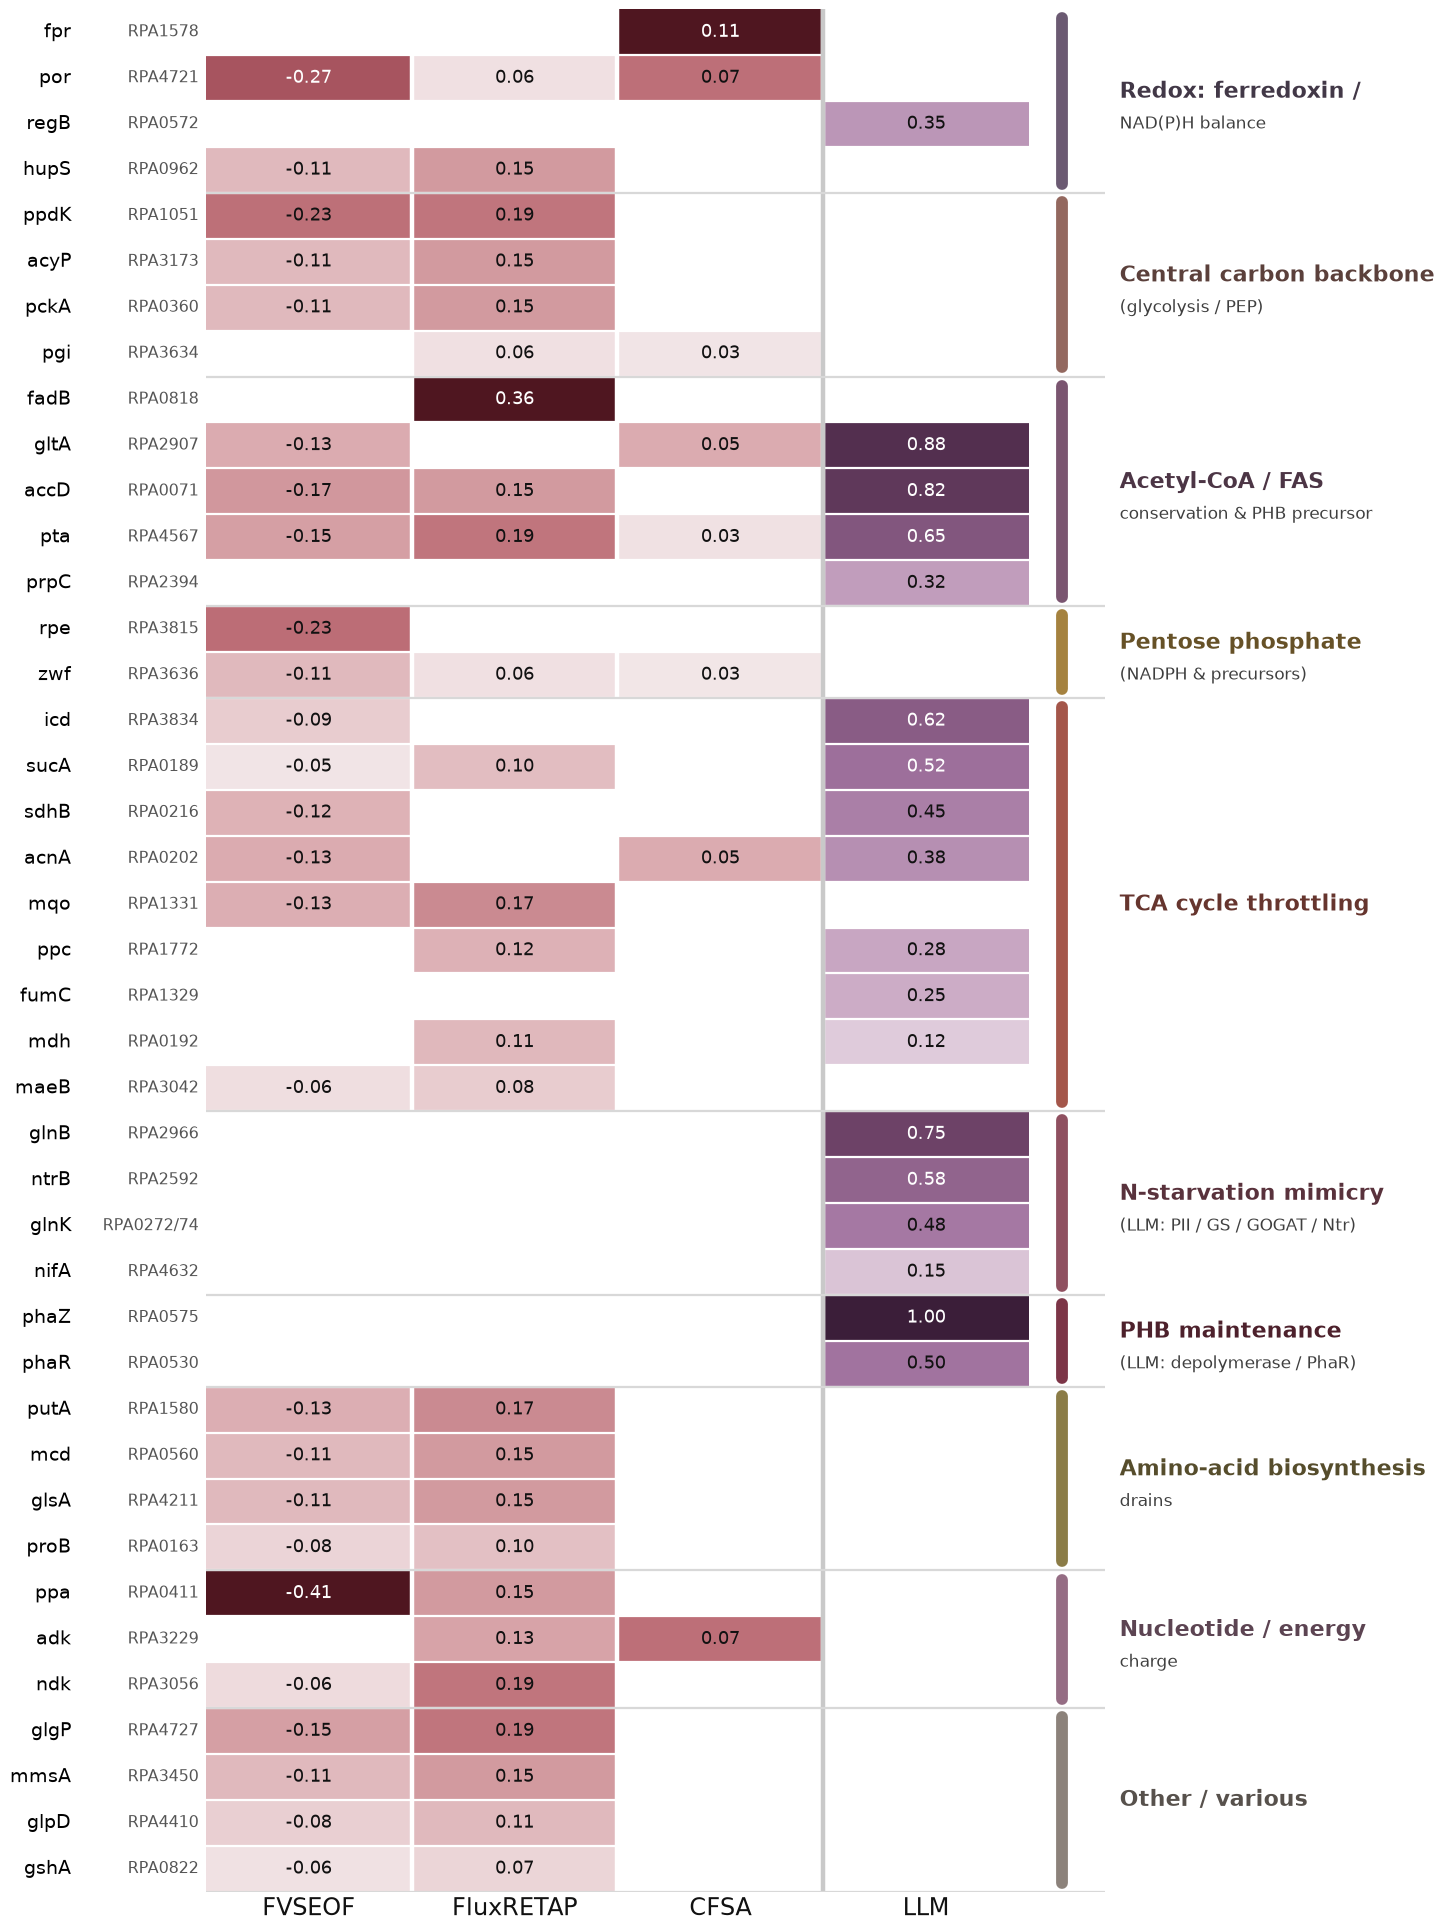

In [5]:
heatmap_v2(df, "nb04_downselected_refined", caption=False)   # caption=True adds a small colour-legend line at the top

## Part 3 · Method-overlap Euler diagram

A second view of the same 41 targets: an **area-proportional 4-set Euler diagram** of which methods flag
which genes. Each ellipse is one method; its **area is proportional to how many of the 41 it flags**
(FVSEOF 26, FluxRETAP 26, CFSA 8, LLM 18) and the overlaps are least-squares-fit so shared counts read as
shared area (all four ellipses stay proportional; the shapes vary to make every region fit). A gene counts
toward a method if it has a value in that method's column — for LLM, that means it carries a literature
prior. The ellipse geometry is **pre-fit and pinned** (`EU_ELL`) so the figure reproduces exactly and
instantly; the raw fit is a `scipy` optimisation over the region areas.

**Reads:** FVSEOF and FluxRETAP are nearly identical (both flux-response — they share 21 of ~26 each, the
big central lens); **the LLM adds 9 unique** model-blind regulators (bottom-right); CFSA is the most selective;
and **`pta` is the one target all four methods agree on** (the central `1`). Written to
`Results/nb60_targets/figures/nb04_method_overlap_euler.{png,svg}`.

set sizes: {'FVSEOF': 26, 'FluxRETAP': 26, 'CFSA': 8, 'LLM': 18} | total 41


saved C:\Users\jscom\OneDrive\Documents\CGA009_GSM\Release_github\Results\nb60_targets\figures\nb04_method_overlap_euler.png


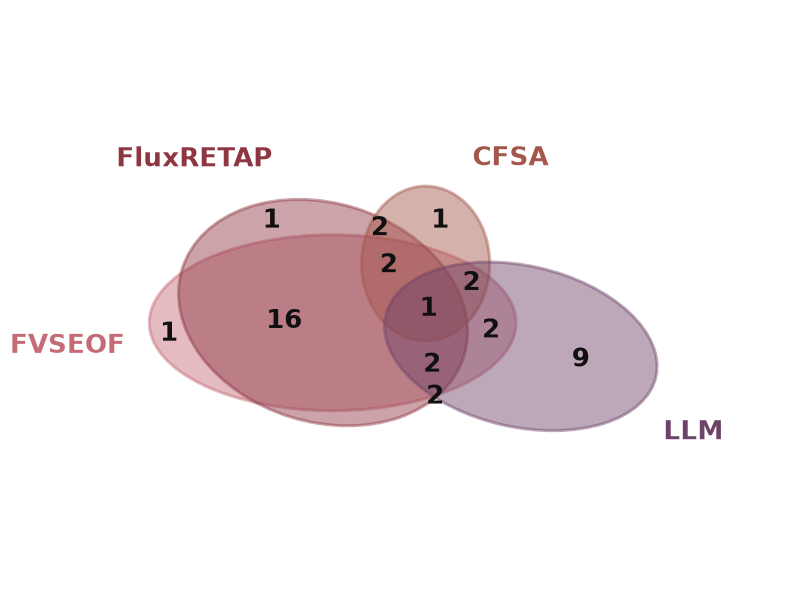

In [6]:
from matplotlib.patches import Ellipse as _Ell
from scipy import ndimage as _ndi
from collections import Counter as _Counter
import math as _m

EU_SETS = ["FVSEOF", "FluxRETAP", "CFSA", "LLM"]   # display labels (CFSA = sampling method; LLM = literature-prior)
EU_COL  = {"FVSEOF": "#c56b76", "FluxRETAP": "#8e3743", "CFSA": "#a4564a", "LLM": "#6e4368"}  # target-list colours
# pre-fit ellipse geometry (cx, cy, semi-a, semi-b, theta_rad): area ∝ set size, overlaps fit to the counts
EU_ELL = [(0.39071, 0.47122, 0.62588, 0.30014,  0.00003),   # FVSEOF
          (0.35794, 0.50596, 0.50334, 0.37321, -0.30044),   # FluxRETAP
          (0.70798, 0.67333, 0.21874, 0.26424,  0.00135),   # CASOP
          (1.03298, 0.39073, 0.47270, 0.27512, -0.22116)]   # AI

_gm = NB._STATE["gmraw"]
def _member(r):    # which methods flag this target (F, R, C, A)
    bg = r.blue_gene
    return (bg in _gm["FVSEOF"], bg in _gm["FluxRETAP"], bg in _gm["CASOP"], r.ai_pred == r.ai_pred)
_cnt = _Counter(_member(r) for _, r in df.iterrows())
print("set sizes:", {EU_SETS[i]: sum(m[i] for m in _cnt.elements()) for i in range(4)}, "| total", sum(_cnt.values()))

def _inside(px, py, e):
    cx, cy, a, b, th = e; ct, st = _m.cos(th), _m.sin(th)
    dx, dy = px - cx, py - cy; xr = dx*ct + dy*st; yr = -dx*st + dy*ct
    return (xr/a)**2 + (yr/b)**2 <= 1.0

fig, ax = plt.subplots(figsize=(9.4, 8.8))
for e, s in zip(EU_ELL, EU_SETS):
    cx, cy, a, b, th = e
    ax.add_patch(_Ell((cx, cy), 2*a, 2*b, angle=_m.degrees(th), facecolor=EU_COL[s],
                      alpha=0.46, edgecolor=EU_COL[s], lw=2.2, zorder=1))
# region grid -> each intersection count at its region's most-interior point
NG = 1000
gx = np.linspace(-0.35, 1.35, NG); gy = np.linspace(-0.30, 1.30, NG); GX, GY = np.meshgrid(gx, gy)
_codeg = np.zeros((NG, NG), int)
for i, e in enumerate(EU_ELL): _codeg += _inside(GX, GY, e).astype(int) << i
_labels = []
for code, n in _cnt.items():
    if not any(code): continue
    ci = sum((int(b) << i) for i, b in enumerate(code)); reg = (_codeg == ci)
    if reg.sum() < 25: continue
    dt = _ndi.distance_transform_edt(reg); iy, ix = np.unravel_index(np.argmax(dt), dt.shape)
    _labels.append([gx[ix], gy[iy], str(n)])
# nudge apart any two count-labels sitting too close (keeps overlapping regions' numbers readable)
_pos = np.array([[l[0], l[1]] for l in _labels], float); _MIND = 0.080
for _ in range(300):
    _moved = False
    for u in range(len(_pos)):
        for v in range(u+1, len(_pos)):
            dd = _pos[u] - _pos[v]; dist = _m.hypot(*dd)
            if 1e-9 < dist < _MIND:
                w = dd/dist; sh = (_MIND-dist)/2; _pos[u] += w*sh; _pos[v] -= w*sh; _moved = True
    if not _moved: break
for (_, _, txt), (px, py) in zip(_labels, _pos):
    ax.text(px, py, txt, ha="center", va="center", fontsize=19, fontweight="bold", color="#101010", zorder=3)
# method names off each ellipse's most-exposed boundary point (out in open space)
_tt = np.linspace(0, 2*np.pi, 1440)
for i, s in enumerate(EU_SETS):
    cx, cy, aa, bb, th = EU_ELL[i]; ct, st = _m.cos(th), _m.sin(th)
    bx = cx + aa*np.cos(_tt)*ct - bb*np.sin(_tt)*st; by = cy + aa*np.cos(_tt)*st + bb*np.sin(_tt)*ct
    clr = np.full(_tt.shape, np.inf)
    for j, ej in enumerate(EU_ELL):
        if j == i: continue
        cxj, cyj, aj, bj, tj = ej; cjt, sjt = _m.cos(tj), _m.sin(tj)
        dxr = (bx-cxj)*cjt + (by-cyj)*sjt; dyr = -(bx-cxj)*sjt + (by-cyj)*cjt
        clr = np.minimum(clr, (dxr/aj)**2 + (dyr/bj)**2 - 1.0)
    k = int(np.argmax(clr)); dv = np.array([bx[k]-cx, by[k]-cy]); dv = dv/(np.hypot(*dv)+1e-9)
    p = np.array([bx[k], by[k]]) + dv*0.10
    ha = "left" if dv[0] > 0.3 else ("right" if dv[0] < -0.3 else "center")
    va = "bottom" if dv[1] > 0.3 else ("top" if dv[1] < -0.3 else "center")
    ax.text(p[0], p[1], s, ha=ha, va=va, fontsize=19, fontweight="bold", color=EU_COL[s], zorder=4, clip_on=False)
_xy = np.array([[e[0], e[1]] for e in EU_ELL]); _am = max(e[2] for e in EU_ELL)
ax.set_xlim(_xy[:,0].min()-_am-0.28, _xy[:,0].max()+_am+0.28); ax.set_ylim(_xy[:,1].min()-_am-0.24, _xy[:,1].max()+_am+0.24)
ax.set_aspect("equal"); ax.axis("off")
for ext in ("png", "svg"):
    fig.savefig(L.FIG / f"nb04_method_overlap_euler.{ext}", bbox_inches="tight", dpi=170, facecolor="white")
print("saved", L.FIG / "nb04_method_overlap_euler.png"); plt.show()